In [60]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np

base_path = "/content/drive/MyDrive/POINTER2026_MiniProject/dataset/"

In [3]:
train = pd.read_csv(base_path + "train.csv", sep=";")
test = pd.read_csv(base_path + "test.csv", sep=";")
sample = pd.read_csv(base_path + "sample_submission.csv", sep=";")

print("Train:", train.shape)
print("Test:", test.shape)
print("Sample Submission:", sample.shape)

train.head()

Train: (734, 13)
Test: (184, 12)
Sample Submission: (184, 2)


,id,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,1,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,2,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,3,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,4,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,5,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 734 entries, 0 to 733
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              734 non-null    int64  
 1   Age             734 non-null    int64  
 2   Sex             734 non-null    object 
 3   ChestPainType   734 non-null    object 
 4   RestingBP       734 non-null    int64  
 5   Cholesterol     734 non-null    int64  
 6   FastingBS       734 non-null    int64  
 7   RestingECG      734 non-null    object 
 8   MaxHR           734 non-null    int64  
 9   ExerciseAngina  734 non-null    object 
 10  Oldpeak         734 non-null    float64
 11  ST_Slope        734 non-null    object 
 12  HeartDisease    734 non-null    int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 74.7+ KB


In [5]:
train.isnull().sum()

,0
id,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0


In [6]:
train.duplicated().sum()

np.int64(0)

In [7]:
train["HeartDisease"].value_counts()

,count
HeartDisease,
1,401
0,333


In [8]:
print("Kolom train:")
print(train.columns.tolist())

print("\nKolom test:")
print(test.columns.tolist())

Kolom train:
['id', 'Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']

Kolom test:
['id', 'Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']


In [9]:
train["HeartDisease"].value_counts()

,count
HeartDisease,
1,401
0,333


In [10]:
target_count = train["HeartDisease"].value_counts()
target_percent = train["HeartDisease"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "Jumlah": target_count,
    "Persentase (%)": target_percent.round(2)
})

target_summary

,Jumlah,Persentase (%)
HeartDisease,,
1,401,54.63
0,333,45.37


In [11]:
train.describe()

,id,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000
mean,461.389646,53.651226,133.064033,199.683924,0.227520,136.178474,0.905041,0.546322
std,267.255825,9.364290,18.438941,108.216855,0.419517,25.329254,1.082952,0.498189
min,1.000000,29.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,227.500000,47.000000,120.000000,177.000000,0.000000,118.000000,0.000000,0.000000
50%,461.500000,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,693.750000,60.000000,140.000000,269.000000,0.000000,155.000000,1.500000,1.000000
max,918.000000,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [12]:
print("Jumlah Cholesterol = 0 di train:", (train["Cholesterol"] == 0).sum())
print("Jumlah RestingBP = 0 di train:", (train["RestingBP"] == 0).sum())

print("Jumlah Cholesterol = 0 di test:", (test["Cholesterol"] == 0).sum())
print("Jumlah RestingBP = 0 di test:", (test["RestingBP"] == 0).sum())

Jumlah Cholesterol = 0 di train: 137
Jumlah RestingBP = 0 di train: 1
Jumlah Cholesterol = 0 di test: 35
Jumlah RestingBP = 0 di test: 0


In [13]:
categorical_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]

for col in categorical_cols:
    print(f"\nKolom: {col}")
    print(train[col].value_counts())


Kolom: Sex
Sex
M    568
F    166
Name: count, dtype: int64

Kolom: ChestPainType
ChestPainType
ASY    401
NAP    162
ATA    139
TA      32
Name: count, dtype: int64

Kolom: RestingECG
RestingECG
Normal    444
LVH       149
ST        141
Name: count, dtype: int64

Kolom: ExerciseAngina
ExerciseAngina
N    431
Y    303
Name: count, dtype: int64

Kolom: ST_Slope
ST_Slope
Flat    379
Up      307
Down     48
Name: count, dtype: int64


In [14]:
numeric_cols = ["Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak"]
categorical_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]

print("Kolom numerik:", numeric_cols)
print("Kolom kategorikal:", categorical_cols)

Kolom numerik: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
Kolom kategorikal: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


In [15]:
for col in categorical_cols:
    print(f"\nDistribusi {col} terhadap HeartDisease:")
    display(pd.crosstab(train[col], train["HeartDisease"], normalize="index").round(2))


Distribusi Sex terhadap HeartDisease:


HeartDisease,0,1
Sex,,
F,0.75,0.25
M,0.37,0.63



Distribusi ChestPainType terhadap HeartDisease:


HeartDisease,0,1
ChestPainType,,
ASY,0.23,0.77
ATA,0.86,0.14
NAP,0.64,0.36
TA,0.56,0.44



Distribusi RestingECG terhadap HeartDisease:


HeartDisease,0,1
RestingECG,,
LVH,0.44,0.56
Normal,0.49,0.51
ST,0.35,0.65



Distribusi ExerciseAngina terhadap HeartDisease:


HeartDisease,0,1
ExerciseAngina,,
N,0.67,0.33
Y,0.14,0.86



Distribusi ST_Slope terhadap HeartDisease:


HeartDisease,0,1
ST_Slope,,
Down,0.23,0.77
Flat,0.18,0.82
Up,0.82,0.18


In [16]:
train.groupby("HeartDisease")[numeric_cols].mean().round(2)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak
HeartDisease,,,,,,
0,50.58,130.26,229.58,0.11,147.70,0.40
1,56.20,135.39,174.86,0.33,126.61,1.32


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

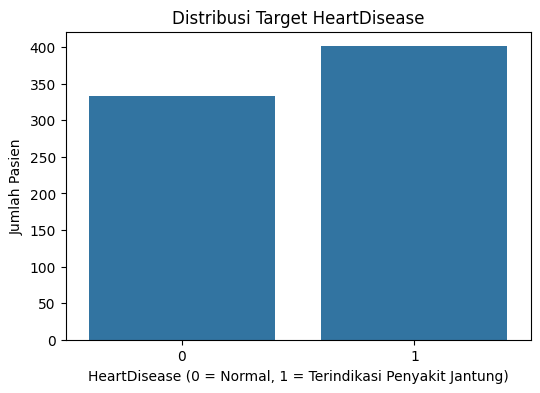

In [18]:
plt.figure(figsize=(6, 4))
sns.countplot(data=train, x="HeartDisease")
plt.title("Distribusi Target HeartDisease")
plt.xlabel("HeartDisease (0 = Normal, 1 = Terindikasi Penyakit Jantung)")
plt.ylabel("Jumlah Pasien")
plt.show()

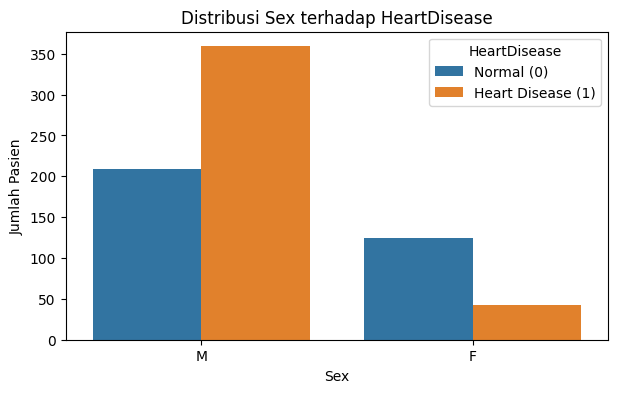

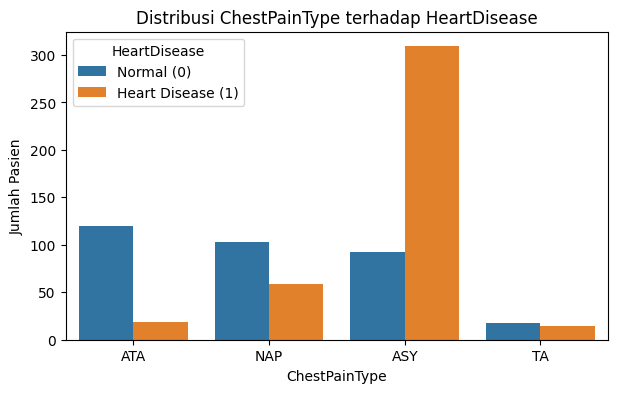

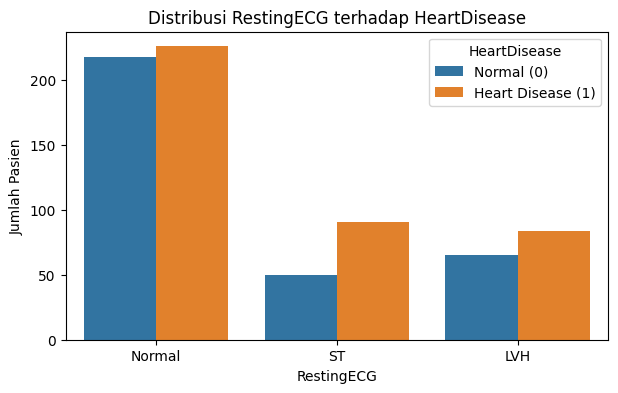

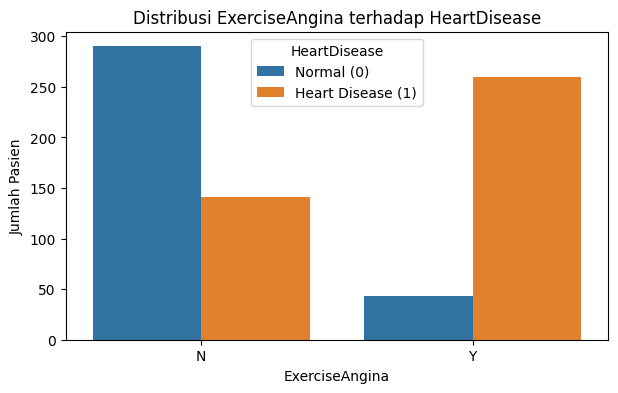

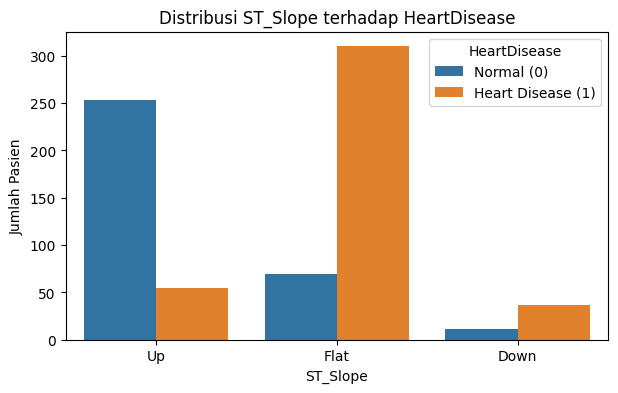

In [19]:
categorical_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]

for col in categorical_cols:
    plt.figure(figsize=(7, 4))
    sns.countplot(data=train, x=col, hue="HeartDisease")
    plt.title(f"Distribusi {col} terhadap HeartDisease")
    plt.xlabel(col)
    plt.ylabel("Jumlah Pasien")
    plt.legend(title="HeartDisease", labels=["Normal (0)", "Heart Disease (1)"])
    plt.show()

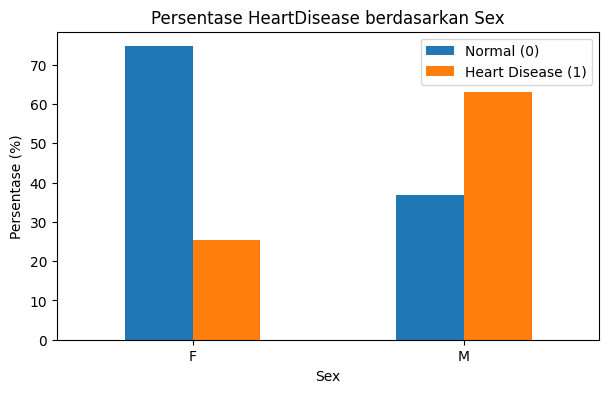

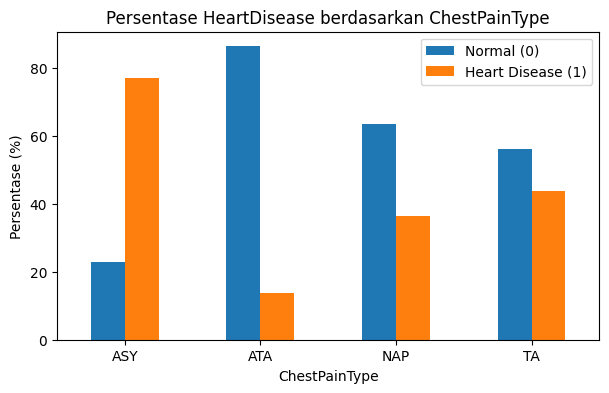

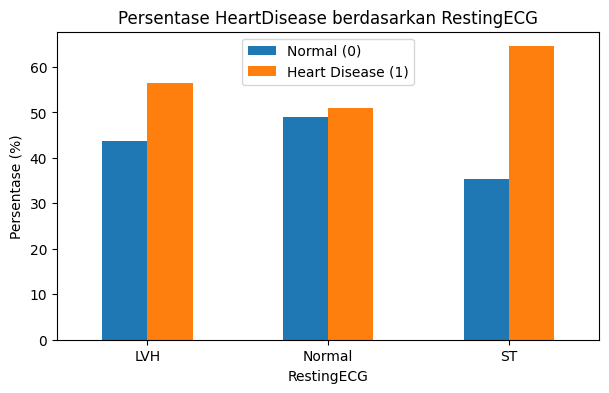

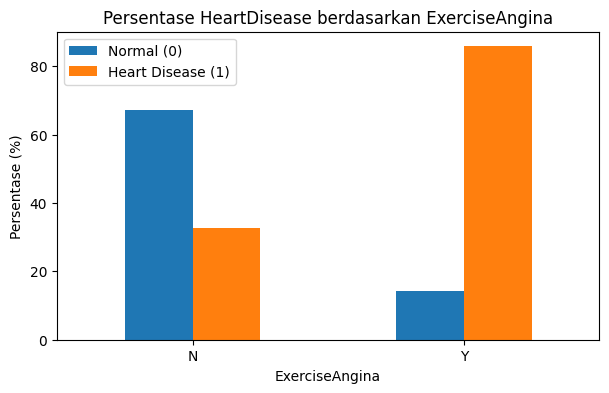

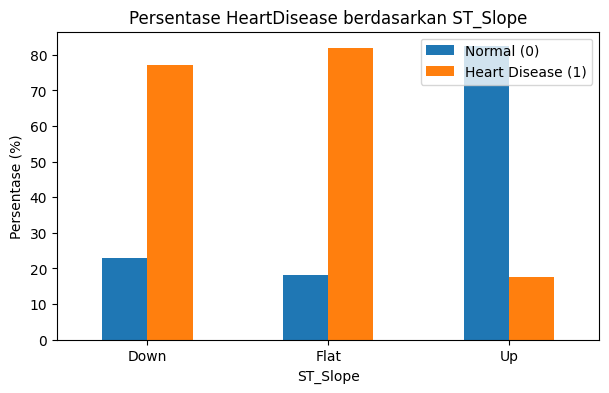

In [20]:
for col in categorical_cols:
    prop_table = pd.crosstab(train[col], train["HeartDisease"], normalize="index") * 100

    prop_table.plot(kind="bar", figsize=(7, 4))
    plt.title(f"Persentase HeartDisease berdasarkan {col}")
    plt.xlabel(col)
    plt.ylabel("Persentase (%)")
    plt.legend(["Normal (0)", "Heart Disease (1)"])
    plt.xticks(rotation=0)
    plt.show()

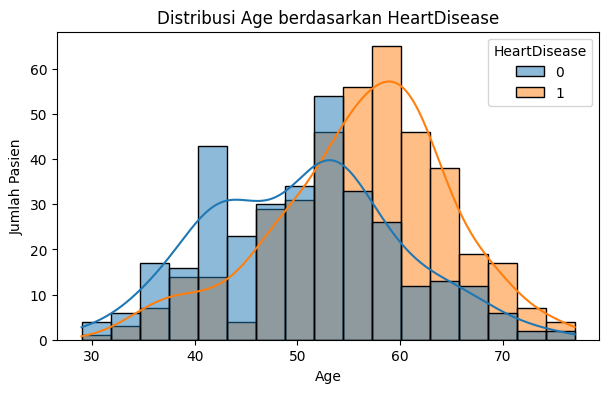

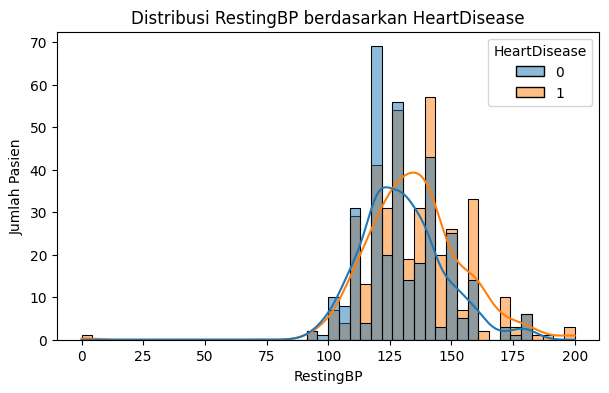

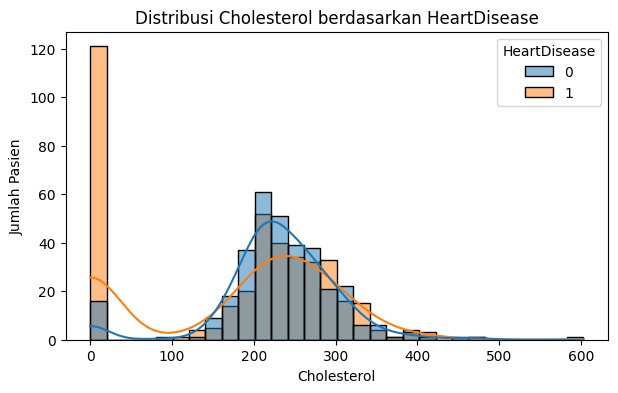

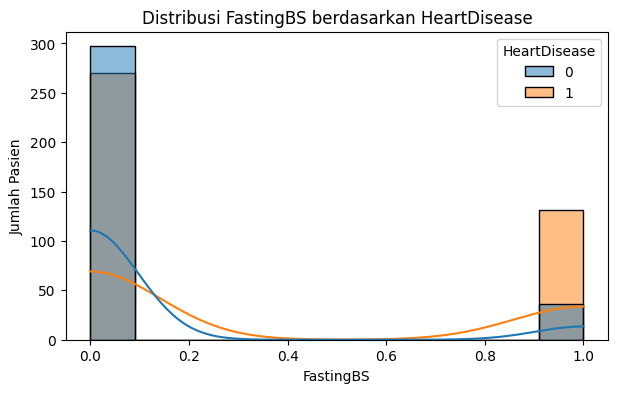

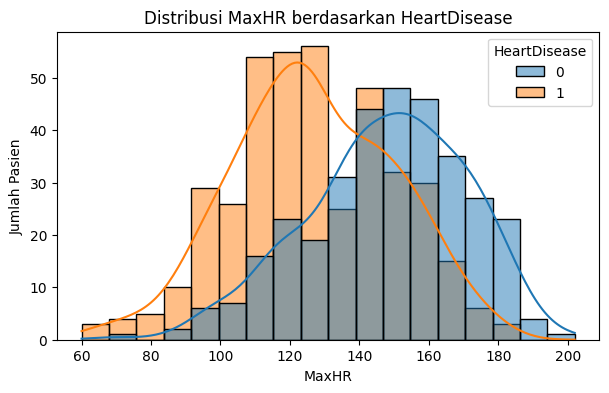

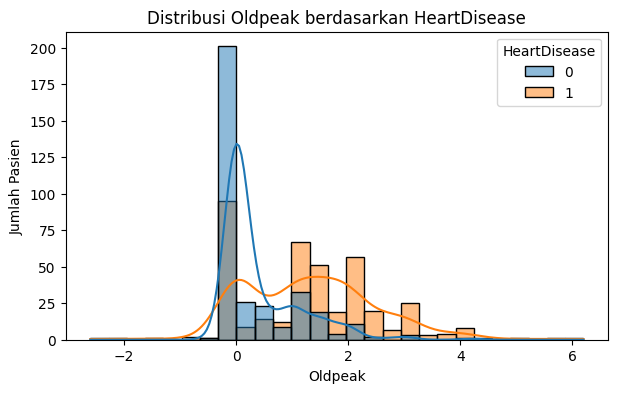

In [21]:
numeric_cols = ["Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak"]

for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=train, x=col, hue="HeartDisease", kde=True)
    plt.title(f"Distribusi {col} berdasarkan HeartDisease")
    plt.xlabel(col)
    plt.ylabel("Jumlah Pasien")
    plt.show()

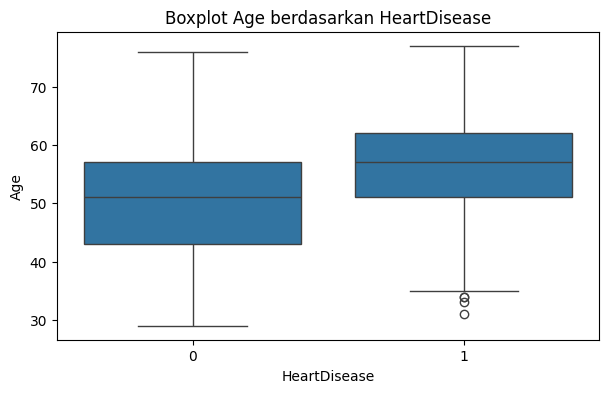

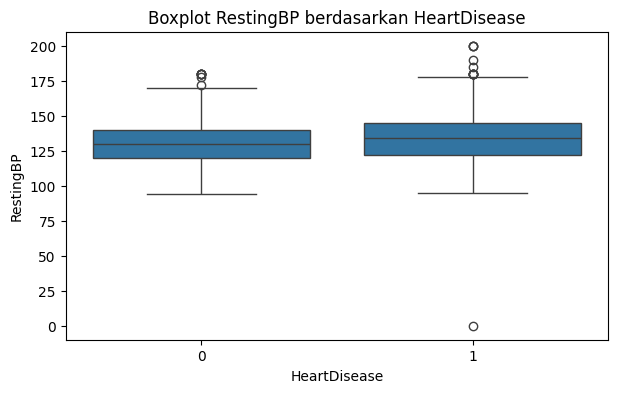

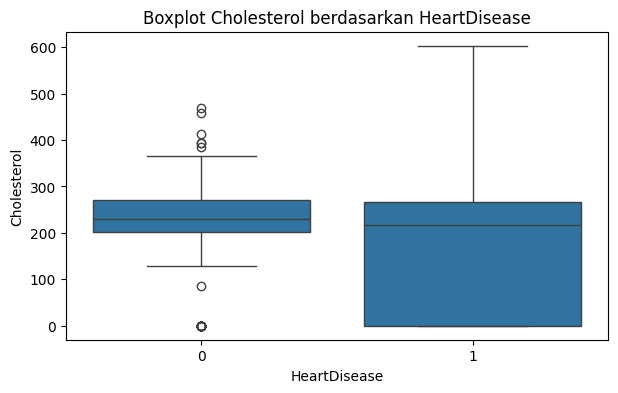

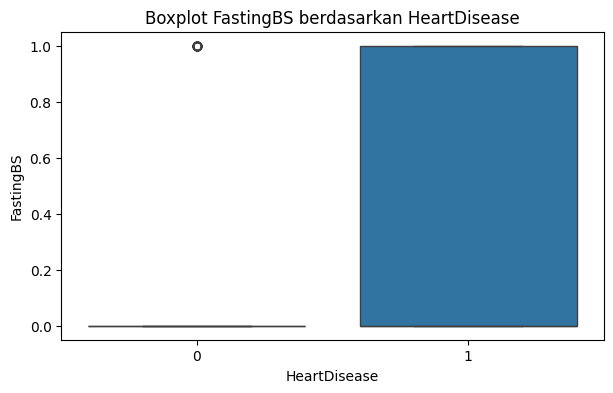

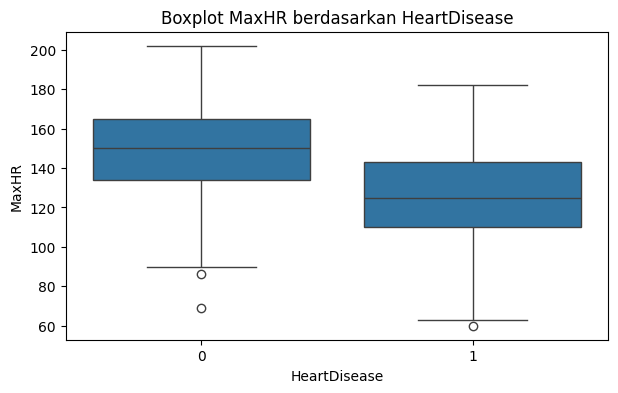

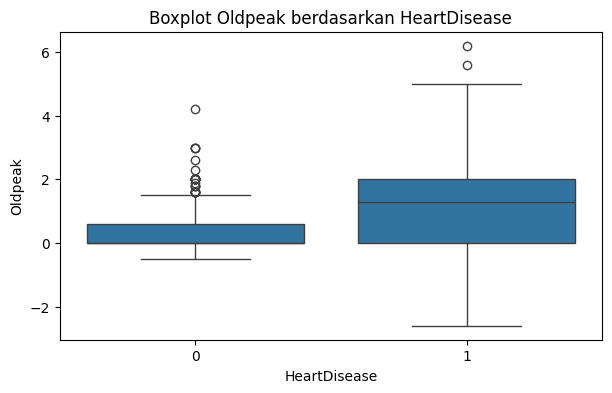

In [22]:
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=train, x="HeartDisease", y=col)
    plt.title(f"Boxplot {col} berdasarkan HeartDisease")
    plt.xlabel("HeartDisease")
    plt.ylabel(col)
    plt.show()

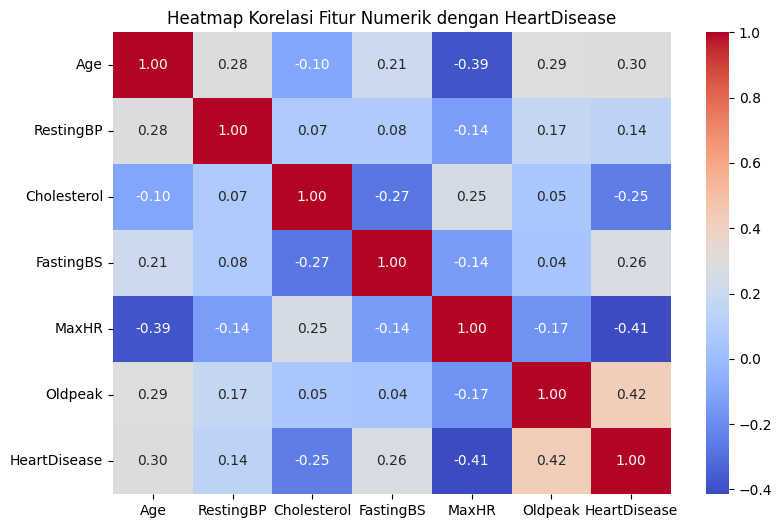

In [23]:
plt.figure(figsize=(9, 6))
corr = train[numeric_cols + ["HeartDisease"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap Korelasi Fitur Numerik dengan HeartDisease")
plt.show()

In [24]:
print("Rata-rata fitur numerik berdasarkan HeartDisease:")
display(train.groupby("HeartDisease")[numeric_cols].mean().round(2))

print("\nDistribusi fitur kategorikal terhadap HeartDisease:")
for col in categorical_cols:
    print(f"\n{col}")
    display(pd.crosstab(train[col], train["HeartDisease"], normalize="index").round(2))

Rata-rata fitur numerik berdasarkan HeartDisease:


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak
HeartDisease,,,,,,
0,50.58,130.26,229.58,0.11,147.70,0.40
1,56.20,135.39,174.86,0.33,126.61,1.32



Distribusi fitur kategorikal terhadap HeartDisease:

Sex


HeartDisease,0,1
Sex,,
F,0.75,0.25
M,0.37,0.63



ChestPainType


...

HeartDisease,0,1
RestingECG,,
LVH,0.44,0.56
Normal,0.49,0.51
ST,0.35,0.65



ExerciseAngina


HeartDisease,0,1
ExerciseAngina,,
N,0.67,0.33
Y,0.14,0.86



ST_Slope


HeartDisease,0,1
ST_Slope,,
Down,0.23,0.77
Flat,0.18,0.82
Up,0.82,0.18


In [25]:
train_clean = train.copy()
test_clean = test.copy()

In [26]:
train_clean["Cholesterol_is_zero"] = (train_clean["Cholesterol"] == 0).astype(int)
test_clean["Cholesterol_is_zero"] = (test_clean["Cholesterol"] == 0).astype(int)

train_clean["RestingBP_is_zero"] = (train_clean["RestingBP"] == 0).astype(int)
test_clean["RestingBP_is_zero"] = (test_clean["RestingBP"] == 0).astype(int)

In [27]:
train_clean["Cholesterol"] = train_clean["Cholesterol"].replace(0, np.nan)
test_clean["Cholesterol"] = test_clean["Cholesterol"].replace(0, np.nan)

train_clean["RestingBP"] = train_clean["RestingBP"].replace(0, np.nan)
test_clean["RestingBP"] = test_clean["RestingBP"].replace(0, np.nan)

In [28]:
X = train_clean.drop(columns=["HeartDisease"])
y = train_clean["HeartDisease"]

X_test = test_clean.copy()

In [29]:
X = X.drop(columns=["id"])
X_test_id = X_test["id"]
X_test = X_test.drop(columns=["id"])

In [30]:
numeric_cols = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "FastingBS",
    "MaxHR",
    "Oldpeak",
    "Cholesterol_is_zero",
    "RestingBP_is_zero"
]

categorical_cols = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [32]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [33]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [34]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

print("\nDistribusi y_train:")
print(y_train.value_counts(normalize=True).round(2))

print("\nDistribusi y_val:")
print(y_val.value_counts(normalize=True).round(2))

X_train: (587, 13)
X_val: (147, 13)
y_train: (587,)
y_val: (147,)

Distribusi y_train:
HeartDisease
1    0.55
0    0.45
Name: proportion, dtype: float64

Distribusi y_val:
HeartDisease
1    0.54
0    0.46
Name: proportion, dtype: float64


In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

from sklearn.base import clone

In [36]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),

    "SVC": SVC(
        C=2,
        kernel="rbf",
        gamma="scale",
        class_weight="balanced",
        probability=True,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=15
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=4,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=75,
        learning_rate=0.8,
        random_state=42
    )
}

In [37]:
trained_models = {}
results = []

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", clone(model))
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)

    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average="macro")
    precision = precision_score(y_val, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_val, y_pred, average="macro", zero_division=0)

    trained_models[model_name] = pipeline

    results.append({
        "Model": model_name,
        "Accuracy": acc,
        "F1 Macro": f1,
        "Precision Macro": precision,
        "Recall Macro": recall
    })

results_df = pd.DataFrame(results).sort_values(by="F1 Macro", ascending=False)
results_df

,Model,Accuracy,F1 Macro,Precision Macro,Recall Macro
2,KNN,0.884354,0.882173,0.889368,0.879198
0,Logistic Regression,0.870748,0.869199,0.871235,0.867910
5,Gradient Boosting,0.870748,0.868781,0.872960,0.866698
1,SVC,0.863946,0.863179,0.862598,0.864086
4,Random Forest,0.863946,0.862101,0.865079,0.860448
6,AdaBoost,0.857143,0.855430,0.857398,0.854198
3,Decision Tree,0.823129,0.821268,0.822326,0.820522


In [38]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Model terbaik berdasarkan F1 Macro:", best_model_name)
display(results_df)

Model terbaik berdasarkan F1 Macro: KNN


,Model,Accuracy,F1 Macro,Precision Macro,Recall Macro
2,KNN,0.884354,0.882173,0.889368,0.879198
0,Logistic Regression,0.870748,0.869199,0.871235,0.867910
5,Gradient Boosting,0.870748,0.868781,0.872960,0.866698
1,SVC,0.863946,0.863179,0.862598,0.864086
4,Random Forest,0.863946,0.862101,0.865079,0.860448
6,AdaBoost,0.857143,0.855430,0.857398,0.854198
3,Decision Tree,0.823129,0.821268,0.822326,0.820522


Classification Report Model Terbaik:
              precision    recall  f1-score   support

           0       0.92      0.82      0.87        67
           1       0.86      0.94      0.90        80

    accuracy                           0.88       147
   macro avg       0.89      0.88      0.88       147
weighted avg       0.89      0.88      0.88       147



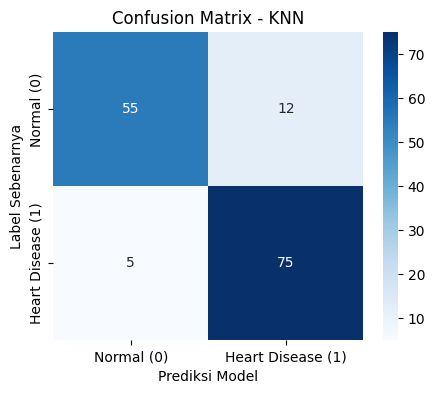

In [39]:
y_pred_best = best_model.predict(X_val)

print("Classification Report Model Terbaik:")
print(classification_report(y_val, y_pred_best))

cm = confusion_matrix(y_val, y_pred_best)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal (0)", "Heart Disease (1)"],
    yticklabels=["Normal (0)", "Heart Disease (1)"]
)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Prediksi Model")
plt.ylabel("Label Sebenarnya")
plt.show()

,Feature,Importance
10,ST_Slope,0.055904
9,Oldpeak,0.040872
11,Cholesterol_is_zero,0.038495
8,ExerciseAngina,0.033419
2,ChestPainType,0.020583
7,MaxHR,0.017594
5,FastingBS,0.008134
6,RestingECG,0.004224
1,Sex,0.003986
0,Age,0.000419


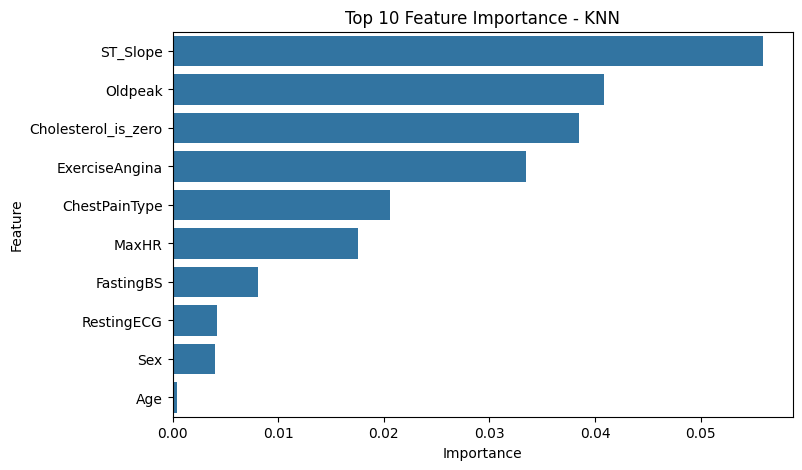

In [40]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    best_model,
    X_val,
    y_val,
    scoring="f1_macro",
    n_repeats=10,
    random_state=42
)

importance_df = pd.DataFrame({
    "Feature": X_val.columns,
    "Importance": perm_importance.importances_mean
}).sort_values(by="Importance", ascending=False)

display(importance_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df.head(10), x="Importance", y="Feature")
plt.title(f"Top 10 Feature Importance - {best_model_name}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [41]:
final_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", clone(models[best_model_name]))
])

final_model.fit(X, y)

print("Final model sudah dilatih menggunakan seluruh data train.")
print("Model final:", best_model_name)

Final model sudah dilatih menggunakan seluruh data train.
Model final: KNN


In [42]:
test_predictions = final_model.predict(X_test)

test_predictions[:10]

array([0, 1, 1, 1, 0, 1, 1, 0, 1, 1])

In [43]:
submission = pd.DataFrame({
    "id": X_test_id,
    "HeartDisease": test_predictions.astype(int)
})

submission.head()

,id,HeartDisease
0,669,0
1,31,1
2,378,1
3,536,1
4,808,0


In [44]:
print("Ukuran submission:", submission.shape)
print("Kolom submission:", submission.columns.tolist())
print("Nilai unik HeartDisease:", submission["HeartDisease"].unique())
print("Jumlah missing value:")
print(submission.isnull().sum())

assert submission.shape[0] == test_clean.shape[0], "Jumlah baris submission tidak sama dengan test.csv"
assert submission.columns.tolist() == ["id", "HeartDisease"], "Kolom submission harus id dan HeartDisease"
assert set(submission["HeartDisease"].unique()).issubset({0, 1}), "HeartDisease hanya boleh 0 atau 1"
assert (submission["id"].values == test_clean["id"].values).all(), "Urutan id harus sama dengan test.csv"

print("Format submission aman.")

Ukuran submission: (184, 2)
Kolom submission: ['id', 'HeartDisease']
Nilai unik HeartDisease: [0 1]
Jumlah missing value:
id              0
HeartDisease    0
dtype: int64
Format submission aman.


In [45]:
import os

GROUP_NAME = "kelompok_33"

output_path = "/content/drive/MyDrive/POINTER2026_MiniProject/output/"
os.makedirs(output_path, exist_ok=True)

submission_file = output_path + GROUP_NAME + "_submission.csv"
reasoning_txt_file = output_path + GROUP_NAME + "_reasoning_draft.txt"

In [46]:
submission.to_csv(submission_file, index=False, sep=";")

print("Submission berhasil disimpan:")
print(submission_file)

Submission berhasil disimpan:
/content/drive/MyDrive/POINTER2026_MiniProject/output/kelompok_33_submission.csv


In [47]:
cek_submission = pd.read_csv(submission_file, sep=";")
cek_submission.head()

,id,HeartDisease
0,669,0
1,31,1
2,378,1
3,536,1
4,808,0


In [48]:
cek_submission.shape

(184, 2)

In [49]:
# Mengambil probabilitas prediksi dari model final
test_proba = final_model.predict_proba(X_test)[:, 1]

reasoning_data = test_clean.copy()
reasoning_data["Predicted_HeartDisease"] = test_predictions.astype(int)
reasoning_data["Probability_HeartDisease"] = test_proba

# Confidence mengikuti kelas prediksi
reasoning_data["Confidence"] = reasoning_data.apply(
    lambda row: row["Probability_HeartDisease"] if row["Predicted_HeartDisease"] == 1
    else 1 - row["Probability_HeartDisease"],
    axis=1
)

reasoning_data.head()

,id,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,Cholesterol_is_zero,RestingBP_is_zero,Predicted_HeartDisease,Probability_HeartDisease,Confidence
0,669,63,F,ATA,140,195.0,0,Normal,179,N,0.0,Up,0,0,0,0.133333,0.866667
1,31,53,M,NAP,145,518.0,0,Normal,130,N,0.0,Flat,0,0,1,0.600000,0.600000
2,378,65,M,ASY,160,NaN,1,ST,122,N,1.2,Flat,1,0,1,1.000000,1.000000
3,536,56,M,ASY,130,NaN,0,LVH,122,Y,1.0,Flat,1,0,1,0.933333,0.933333
4,808,54,M,ATA,108,309.0,0,Normal,156,N,0.0,Up,0,0,0,0.066667,0.933333


In [50]:
# Ambil 2 pasien prediksi HeartDisease = 1 dengan confidence tertinggi
sample_hd = reasoning_data[reasoning_data["Predicted_HeartDisease"] == 1] \
    .sort_values(by="Confidence", ascending=False) \
    .head(2)

# Ambil 2 pasien prediksi HeartDisease = 0 dengan confidence tertinggi
sample_normal = reasoning_data[reasoning_data["Predicted_HeartDisease"] == 0] \
    .sort_values(by="Confidence", ascending=False) \
    .head(2)

# Ambil 1 pasien borderline, yaitu probabilitas paling dekat ke 0.5
sample_borderline = reasoning_data.iloc[
    (reasoning_data["Probability_HeartDisease"] - 0.5).abs().sort_values().index
].head(1)

reasoning_samples = pd.concat([sample_hd, sample_normal, sample_borderline]) \
    .drop_duplicates(subset=["id"]) \
    .head(5)

reasoning_samples

,id,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,Cholesterol_is_zero,RestingBP_is_zero,Predicted_HeartDisease,Probability_HeartDisease,Confidence
2,378,65,M,ASY,160,NaN,1,ST,122,N,1.2,Flat,1,0,1,1.000000,1.000000
48,351,53,M,ASY,120,NaN,1,Normal,120,N,0.0,Flat,1,0,1,1.000000,1.000000
31,656,40,M,ASY,152,223.0,0,Normal,181,N,0.0,Up,0,0,0,0.000000,1.000000
28,867,44,M,ATA,130,219.0,0,LVH,188,N,0.0,Up,0,0,0,0.000000,1.000000
5,794,67,M,ASY,125,254.0,1,Normal,163,N,0.2,Flat,0,0,1,0.533333,0.533333


In [51]:
def explain_chest_pain(value):
    mapping = {
        "TA": "Typical Angina, yaitu nyeri dada khas yang biasanya berkaitan dengan masalah jantung.",
        "ATA": "Atypical Angina, yaitu nyeri dada tidak khas.",
        "NAP": "Non-Anginal Pain, yaitu nyeri dada yang bukan tipe angina.",
        "ASY": "Asymptomatic, yaitu tidak menunjukkan gejala nyeri dada yang jelas."
    }
    return mapping.get(value, str(value))

def explain_resting_ecg(value):
    mapping = {
        "Normal": "hasil EKG saat istirahat normal.",
        "ST": "terdapat kelainan ST-T pada hasil EKG.",
        "LVH": "terdapat indikasi hipertrofi ventrikel kiri pada hasil EKG."
    }
    return mapping.get(value, str(value))

def explain_exercise_angina(value):
    return "mengalami angina saat olahraga" if value == "Y" else "tidak mengalami angina saat olahraga"

def explain_st_slope(value):
    mapping = {
        "Up": "segmen ST naik, yang cenderung lebih baik dibanding Flat/Down.",
        "Flat": "segmen ST datar, yang dapat menjadi sinyal risiko dalam konteks pemeriksaan jantung.",
        "Down": "segmen ST menurun, yang dapat menjadi sinyal risiko dalam konteks pemeriksaan jantung."
    }
    return mapping.get(value, str(value))

In [52]:
top_features_text = ", ".join(importance_df.head(5)["Feature"].tolist()) if "importance_df" in globals() else "ST_Slope, Oldpeak, ExerciseAngina, ChestPainType, MaxHR"

def build_reasoning_prompt(row):
    prediction_label = "HEART DISEASE (1)" if row["Predicted_HeartDisease"] == 1 else "NORMAL (0)"
    confidence = row["Confidence"] * 100

    prompt = f"""
Buat reasoning klinis singkat dalam Bahasa Indonesia untuk hasil prediksi model machine learning.

Format jawaban:
Pasien ID: #{row['id']}
Prediksi Model: {prediction_label}
Confidence Score: {confidence:.1f}%

Reasoning:
Jelaskan alasan prediksi berdasarkan fitur klinis pasien berikut. Gunakan bahasa yang jelas, tidak terlalu panjang, dan jangan menyatakan diagnosis pasti. Gunakan istilah "terindikasi" atau "berdasarkan pola data".

Data Pasien:
- Age: {row['Age']} tahun
- Sex: {row['Sex']}
- ChestPainType: {row['ChestPainType']} ({explain_chest_pain(row['ChestPainType'])})
- RestingBP: {row['RestingBP']} mmHg
- Cholesterol: {row['Cholesterol']} mg/dl
- FastingBS: {row['FastingBS']}
- RestingECG: {row['RestingECG']} ({explain_resting_ecg(row['RestingECG'])})
- MaxHR: {row['MaxHR']}
- ExerciseAngina: {row['ExerciseAngina']} ({explain_exercise_angina(row['ExerciseAngina'])})
- Oldpeak: {row['Oldpeak']}
- ST_Slope: {row['ST_Slope']} ({explain_st_slope(row['ST_Slope'])})

Fitur penting dari model:
{top_features_text}

Tutup dengan 1 kalimat kesimpulan bahwa hasil ini hanya alat bantu screening awal, bukan diagnosis final dokter.
"""
    return prompt

In [53]:
!pip -q install transformers accelerate

In [54]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

model_id = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_id)

llm_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)

print("Model LLM berhasil dimuat:", model_id)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model LLM berhasil dimuat: Qwen/Qwen2.5-0.5B-Instruct


In [55]:
def generate_llm_reasoning(prompt):
    messages = [
        {
            "role": "system",
            "content": "Kamu adalah asisten data science yang menjelaskan hasil prediksi model ML untuk screening awal penyakit jantung. Jawab dalam Bahasa Indonesia, jelas, terstruktur, dan tidak berlebihan."
        },
        {
            "role": "user",
            "content": prompt
        }
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer([text], return_tensors="pt").to(llm_model.device)

    outputs = llm_model.generate(
        **inputs,
        max_new_tokens=350,
        do_sample=False
    )

    generated_ids = outputs[0][inputs.input_ids.shape[-1]:]
    response = tokenizer.decode(generated_ids, skip_special_tokens=True)

    return response

In [56]:
reasoning_outputs = []

for idx, row in reasoning_samples.iterrows():
    prompt = build_reasoning_prompt(row)
    reasoning_text = generate_llm_reasoning(prompt)

    reasoning_outputs.append({
        "id": row["id"],
        "Prediction": row["Predicted_HeartDisease"],
        "Confidence": round(row["Confidence"] * 100, 1),
        "Prompt": prompt,
        "Reasoning": reasoning_text
    })

reasoning_results = pd.DataFrame(reasoning_outputs)

reasoning_results[["id", "Prediction", "Confidence", "Reasoning"]]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


,id,Prediction,Confidence,Reasoning
0,378,1,100.0,Pasien ID: #378\nPrediksi Model: HEART DISEASE...
1,351,1,100.0,Pasien ID: #351\nPrediksi Model: HEART DISEASE...
2,656,0,100.0,Pasien ID: #656\nPrediksi Model: NORMAL (0)\nC...
3,867,0,100.0,Pasien ID: #867\nPrediksi Model: NORMAL (0)\nC...
4,794,1,53.3,Pasien ID: #794\nPrediksi Model: HEART DISEASE...


In [57]:
reasoning_csv_file = output_path + GROUP_NAME + "_reasoning_results.csv"
reasoning_txt_file = output_path + GROUP_NAME + "_reasoning.txt"

reasoning_results.to_csv(reasoning_csv_file, index=False, sep=";")

with open(reasoning_txt_file, "w", encoding="utf-8") as f:
    f.write("Dokumen Reasoning LLM - Mini Project POINTER 2026\n")
    f.write("=" * 60 + "\n\n")
    f.write(f"Model Machine Learning Terbaik: {best_model_name}\n")
    f.write("Tujuan: Menjelaskan 5 sampel hasil prediksi HeartDisease.\n\n")

    for i, row in reasoning_results.iterrows():
        f.write(f"Sampel {i+1}\n")
        f.write("-" * 60 + "\n")
        f.write(row["Reasoning"])
        f.write("\n\n")

print("Reasoning CSV disimpan di:", reasoning_csv_file)
print("Reasoning TXT disimpan di:", reasoning_txt_file)

Reasoning CSV disimpan di: /content/drive/MyDrive/POINTER2026_MiniProject/output/kelompok_33_reasoning_results.csv
Reasoning TXT disimpan di: /content/drive/MyDrive/POINTER2026_MiniProject/output/kelompok_33_reasoning.txt


In [58]:
os.listdir(output_path)

['kelompok_submission.csv',
 'kelompok_reasoning_results.csv',
 'kelompok_reasoning.txt',
 'kelompok_reasoning.pdf',
 'kelompok33_reasoning.pdf',
 'kelompok33_submission.csv',
 'kelompok33_reasoning_results.csv',
 'kelompok33_reasoning.txt',
 'kelompok_33_submission.csv',
 'kelompok_33_reasoning_results.csv',
 'kelompok_33_reasoning.txt']

In [59]:
print("=== FINAL CHECKLIST MINI PROJECT ===")

print("\n1. Submission CSV")
print("File:", submission_file)
print("Shape:", submission.shape)
print("Kolom:", submission.columns.tolist())
print("Nilai unik HeartDisease:", submission["HeartDisease"].unique())
print("ID sesuai test:", (submission["id"].values == test_clean["id"].values).all())

print("\n2. Reasoning LLM")
print("Jumlah sampel reasoning:", len(reasoning_results))
print("Hasil reasoning sudah muncul di tabel reasoning_results dan akan disalin manual ke Google Docs.")



=== FINAL CHECKLIST MINI PROJECT ===

1. Submission CSV
File: /content/drive/MyDrive/POINTER2026_MiniProject/output/kelompok_33_submission.csv
Shape: (184, 2)
Kolom: ['id', 'HeartDisease']
Nilai unik HeartDisease: [0 1]
ID sesuai test: True

2. Reasoning LLM
Jumlah sampel reasoning: 5
Hasil reasoning sudah muncul di tabel reasoning_results dan akan disalin manual ke Google Docs.
